---
$\;$
<center> $⟨\;\boxed{\big|\text{ Project Two }\big|}\;⟩$
    
# <center> ᴘʀᴇᴅɪᴄᴛɪɴɢ ᴀɴᴅ ᴄʟᴀꜱꜱɪꜰʏɪɴɢ ᴏʀʙɪᴛᴀʟ ᴄʜᴀᴏꜱ ᴏꜰ ᴀ ᴘʀᴏᴛᴏɴ-ᴇʟᴇᴄᴛʀᴏɴ-ᴘʀᴏᴛᴏɴ ꜱʏꜱᴛᴇᴍ


---
<center> $\text{PHYS 210}$ $\:$ $|$ $\:$ $\text{Jack Rogers}$ $\:$ $|$ $\:$ $\text{27 November 2025}$
    
---

## $1 \:$  $|$ $\:$**Research Question**

Can we predict whether or not a proton-electron-proton system will form a stable trajectory around two protons based on its initial velocity and how can we classify such orbits based on chaos?

## $2\:$  $|$ $\:$**Context of the Simulation**

In this simulation, we model the $\text{H}_2^+$ molecular ion by fixing two protons at a separation of approximately 1.06 Å ($1.06\times10^{-10} \text{m}$). This distance corresponds to the equilibrium internuclear distance (bond length) of $\text{H}_2^+$ in its ground state as reported in Atkins & Friedman, Molecular Quantum Mechanics (5th ed., Oxford University Press). The electron's starting position is colinear (all particles having $y=0$) with these two protons, placed 1.0 Å from the nearest proton. The mission is to categorize the trajectories an electron can make based on its initial $y$ velocity:

1) The electron **collides** with a protons - i.e. at the end of its trajectory, electron spends most of its time very close to either proton.
2) The electron **escapes** the system entirely - that is, its final x or y distance is greater than a certain threshold.
3) The electron forms a **bounded**, looped trajectory around the protons - i.e. the maximum radius stays bounded during the entire integration time and the total energy of the electron stays in equilibrium ($E_\text{kinetic}+E_\text{potential}<0$). In cases where energy is positive, a warning is provided.

This project places special interest on the last configuration, where a bounded orbit is attained. 

To find which $y$ velocities cause stable orbits and to classify them, two tools are used. A sweep of different $y$ velocities will be run, and their resulting electron orbits will be quantitatively and qualitatively categorized into different complexities. This is done using Fourier transforms on the electron's $y$ motion which will provide a tool for visualizing the level of complexity of the orbits. We then run a diagnostic assessment on the neatness of the Fourier transform to assign the orbit a chaos score. This score is a normalized value that quantitatively describes how chaotic the orbit is.

**In the scope of this project, chaos is defined as the complexity of the shape of the orbit.** An orbit that is slightly elliptical with intricate spirographical structure will be assigned a higher chaos score than an orbit that is a simpler, repetitive petal pattern.

In the end, the project will plot the initial $y$ velocities vs. the assigned chaos score on one plot and provide visual examples of different points to verify its findings.

## $3\:$  $|$ $\:$**Additional Physics**

The base physics for this project is the use of <code>solve_ivp</code>, which numerically integrates the coupled differential equations of motion for the electron under the Coulomb forces of the two protons, allowing us to compute its position and velocity at each point in time, which allows us to graph and analyse the trajectory of an electron about two protons.

The additional physics that this project expands upon are the highly useful Fourier transforms. By applying the transform to the graph of the electron’s y-position over time from the simulation, we obtain a graph which represents the frequencies and their harmonics. If a Fourier transform for an orbit has discrete spectral lines at a few frequencies, then one would call the orbit periodic. Should a Fourier transform reveal a broadband spectrum, where no specific, dominating frequencies are defined, we define the orbit as chaotic.

To quantitatively compare orbital chaoticity, we define a normalized chaos index ranging from 0 to 5, where lower values correspond to more periodic trajectories and higher values indicate more chaotic motion. Values 0-5 were chosen as 5 was deemed a readable number, moreso than than the decimals between 0 and 1. The leading digit being either 0, 1, 2, 3, 4, or 5 offers the reader an immediate indicator on the orbit's nature. This index is constructed by computing diagnostics directly from the simulation data using the <code>chaos_score_from_sol</code> function, including the spectral flatness (analogous to spectral entropy) and time-series roughness of the y-motion. These measures are then combined and normalized to yield a single dimensionless value between 0 and 5.

The method used to normalize between 0 and 5 was spectral entropy. It measures how far the frequencies are apart from one another, and so it is able to distinguish whether a Fourier transform is particularly periodic (one large spike; orderly; low chaocity score) or particularly chaotic (many little spikes; unorderly; high chaocity score). Note that Fourier transforms assume that they are being supplied periodic motion. True chaotic motion does not have periodic motion, but on the timescales on which the project considers, such an assumption works as a 'close enough' measure.

## $4\:$  $|$  $\:$**Programming for the Simulation**

This investigation consists of 4 code blocks. Descriptions of what each block does are provided below.

1) $⟨\:$<code>A</code> $⟩$ Set the initial parameters, <code>solve_ivp</code>, and diagnose final trajectory
1) $⟨\:$<code>B</code> $⟩$ Graphs of electron trajectory, y-motion, & energy over time
2) $⟨\:$<code>C</code> $⟩$ Generate the Fourier Transform of the y-position over time using np.fft and compute diagnostics on Fourier-transformed data to assign chaos scale
3) $⟨\:$<code>D</code> $⟩$ Generate estimate plot of 
$y$-velocity verus chaos scores

---
### $⟨\:$<code>CODE BLOCK A</code> $⟩$ Set the initial parameters, <code>solve_ivp</code>, and diagnose final trajectory

This script models a simple version of the $\text{H}_2^+$ ion described above. It numerically solves the motion of the electron, and then evaluates how the electron's orbit ended up.

1) First, it sets up two fixed protons separated by a realistic distance $1.06\times10^{-10}\text{ m}$ away, the equilibrium distance of the ion. It then places an electron to the right, with an initial velocity that the user inputs.
2) It then simulates the electron trajectory over time / computes energy of system.
3) Classifies the trajectory as collision, escape, stable and prints a report.
4) The four verdicts are:
    - 🔴 **Escape**: The electron escaped the system, defined as the distance from the origin being greater than the escape threshold (if the electron  ends the simulation farther than $10^{-9}\text{ m}$ of the system).
    - 🟡 **Collision**: The electron collided with a proton, defined as the closest approach being less than the collision threshold (if the electron gets closer than $10^{-12}\text{ m}$ of a proton).
    - 🟢 **Bounded**: The electron loops around both protons in a large, bounded orbit. The final total energy must be less than zero. Otherwise, the code prints a warning message.
    - There is also a small bounded orbit, where the electron simply falls into a short trajectory. It is labeled less interesting assigned a white color.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm
from matplotlib.collections import LineCollection
from IPython.display import display, Markdown, HTML, Javascript
import ipywidgets as widgets

# Constants
k = 8.9875517923e9
e = 1.602176634e-19
m_e = 9.10938356e-31

# Proton setup
a = 1.06e-10  # separation of H2+ in meters
protons = np.array([
    [-a/2, 0],  # left proton
    [a/2, 0],  # right proton
])

# Time settings
T_guess = 10e-16
t_span = (0, 100*T_guess)
max_step = T_guess/200


def run_simulation(vy0):
    # Electron initial conditions
    r0 = protons[1, 0] + 1.0e-10  # 1 Å to the right of right proton
    y0 = 0.0
    vx0 = 0.0
    state0 = (r0, y0, vx0, vy0)

    # Differential equations
    def diff_eqns(t, state):
        x, y, vx, vy = state
        ax = 0
        ay = 0
        for px, py in protons:
            dx = x - px
            dy = y - py
            r = np.sqrt(dx**2 + dy**2)
            a_val = -k * e**2 / (m_e * r**3)
            ax += a_val * dx
            ay += a_val * dy 
        if ((x) > 0.5e8):
            print('not stable')
        return (vx, vy, ax, ay)

    # Define time points where solution is evaluated
    num_points = 20000
    t_eval = np.linspace(t_span[0], t_span[1], num_points)

    # Solve ODE
    sol1 = solve_ivp(diff_eqns, t_span, state0, t_eval=t_eval, max_step=max_step)
    x, y, vx, vy = sol1.y

    # Energy calculations
    v2 = vx**2 + vy**2
    KE = 0.5 * m_e * v2
    PE = np.zeros_like(x)
    for px, py in protons:
        r_i = np.sqrt((x - px)**2 + (y - py)**2)
        PE += -k * e**2 / r_i
    E_total = KE + PE

    # Energy drift calculation
    E_initial = E_total[0]
    energy_drift = E_total - E_initial       # absolute drift
    percent_change = (energy_drift / np.abs(E_initial)) * 100  # percent change
    max_percent_change = np.max(np.abs(percent_change))        # maximum percent change

    # Final state
    xf, yf = x[-1], y[-1]
    vxf, vyf = vx[-1], vy[-1]

    # Final-state verdict
    final_dists = [np.sqrt((xf - px)**2 + (yf - py)**2) for px, py in protons]
    closest = np.min(final_dists)

    collision_thresh = 1e-12
    escape_thresh = 1e-9

    verdict = "!!!"
    if closest < collision_thresh:
        verdict = "🟡 | Electron COLLIDED with a proton."
    elif np.sqrt(xf**2 + yf**2) > escape_thresh:
        verdict = "🔴 | Electron ESCAPED the system."
    elif np.ptp(x) > 2 * a and np.ptp(y) > a:
        verdict = "🟢 | Electron formed a BOUNDED orbit."
    else:
        verdict = "⚪ | Electron formed a BOUNDED (uninteresting) orbit."

    # Print output
    print("-------=+=--------")
    print("ɪɴɪᴛɪᴀʟ ᴘᴀʀᴀᴍᴇᴛᴇʀꜱ")
    print("-------=+=--------")
    for i, (px, py) in enumerate(protons, start=1):
        print(f"Initial proton {i} position: ({px:.3e}, {py:.3e})")
    print('')
    print(f"Initial electron position: ({r0:.3e}, {y0:.3e})")
    print(f"Initial electron velocity: ({vx0:.3e}, {vy0:.3e})\n")
    print("---------=+=--------")
    print("ᴛʀᴀᴊᴇᴄᴛᴏʀʏ ʙᴇʜᴀᴠɪᴏᴜʀ")
    print("---------=+=--------")
    print(f"Final electron position: ({xf:.3e}, {yf:.3e})")
    print(f"Final electron velocity: ({vxf:.3e}, {vyf:.3e})")
    print(f"\nFinal KE: {KE[-1]:.3e} J")
    print(f"Final PE: {PE[-1]:.3e} J")
    if E_total[-1] < 0:
        print(f"Final TOTAL energy (KE + PE): {E_total[-1]:.3e} J")
    else:
        print(f"Final TOTAL energy (KE + PE): {E_total[-1]:.3e} J. !!! ENERGY IS NOT CONSERVED !!!")
    print(f"Maximum percent energy change: {max_percent_change:.10f} %")
    print("")
    print("VERDICT:", verdict)

    return sol1, verdict, KE, PE, E_total


sol, verdict, KE, PE, E_total = run_simulation(2.5e6)

---

### $⟨\:$<code>CODE BLOCK B</code> $⟩$  Graphs of electron trajectory, y-motion, & energy over time

This section of code prints graphs that visualize what the function <code>solve_ivp</code> is computing with three plots:
- A plot of the electron trajectory around the protons (with a colorbar to show motion over time).
- Plots the electron's y-coordinate as a function of time, visualizes the y-motion (this is what is analysed with Fourier transforms).
- Plots total, kinetic, and potential energy over time, including a reference line at zero energy (this allows usto check energy conservation).

In [ ]:
def plot_simulation(sol, KE, PE, E_total, protons, verdict, start_offset=1.0e-10):
    # Unpack positions
    x, y = sol.y[0], sol.y[1]
    r0 = protons[1, 0] + start_offset
    y0 = 0.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Orbit plot (colored by time)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='Blues', array=sol.t, linewidth=1.5)
    axes[0].add_collection(lc)

    # Start position
    axes[0].plot(r0, y0, 'x', color='green', markersize=10, label='Start')

    # Plot protons
    for i, (px, py) in enumerate(protons, start=1):
        axes[0].plot(px, py, 'ro', markersize=6, label=f'p⁺{i}' if i == 1 else None)

    # Axis limits
    x_all = np.append(x, protons[:, 0])
    y_all = np.append(y, protons[:, 1])
    margin_factor = 1.2

    if "ESCAPED" in verdict:  # Clip if electron escapes
        clip_range = 5e-10
        x_center = 0.0
        y_center = 0.0
        axes[0].set_xlim(x_center - clip_range, x_center + clip_range)
        axes[0].set_ylim(y_center - clip_range, y_center + clip_range)
    else:
        margin = margin_factor * max(np.ptp(x_all), np.ptp(y_all))
        axes[0].set_xlim(np.min(x_all) - margin, np.max(x_all) + margin)
        axes[0].set_ylim(np.min(y_all) - margin, np.max(y_all) + margin)

    # Colorbar
    cbar = plt.colorbar(lc, ax=axes[0])
    cbar.set_label('Time (s)')

    axes[0].set_title('Trajectory around protons (colored by time)')
    axes[0].set_xlabel('x (m)')
    axes[0].set_ylabel('y (m)')
    axes[0].grid(True)
    axes[0].axis('equal')
    axes[0].legend()

    # y vs time
    axes[1].plot(sol.t, y)
    axes[1].set_title('y Position vs Time')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('y Position (m)')
    axes[1].grid(True)

    # Energy vs time
    axes[2].plot(sol.t, E_total, label='Total Energy', color='black')
    axes[2].plot(sol.t, KE, label='Kinetic', color='coral')
    axes[2].plot(sol.t, PE, label='Potential', color='cornflowerblue')
    axes[2].axhline(0, color='gray', linestyle='--', label='E=0')
    axes[2].set_title('Energy vs Time')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Energy (J)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_simulation(sol, KE, PE, E_total, protons, verdict)

<table>
<tr>
<td>

**Figure 4.1:** Trajectory of electron about two, equidistant protons. Colorbar represents time: green cross is present and represents the starting position.

</td>
<td>

**Figure 4.2:** Plot of y position vs time. Can be visually checked for chaos. Collision orbits typically begin with a periodical wave, but devolves into chaos over time.

</td>
<td>

**Figure 4.3:** Energy vs time for the electron: total, kinetic, and potential. The dashed line shows zero energy for reference.

</td>
</tr>
</table>


---
### $⟨\:$<code>CODE BLOCK C</code> $⟩$ Generate the Fourier Transform of the y-position over time using <code>np.fft</code> and compute diagnostics on Fourier-transformed data to assign chaos scale

This script takes the electron's trajectory from the simulation, which it then computes a chaos score based on the noisiness of the motion. This is done by examining the frequency spectrum (FTT) and roughness of the motion.

1) The function reads the time and y-coordinate electron values from the ODE solution.
2) Since the FTT needs uniform spacing, the code interpolates to evenly spaced points using <code>np.linspace</code>.
3) It then subtracts the mean so that the oscillation is about zero, centering the signal.
4) It then uses <code>np.fft.rfft</code> to generate the frequency spectrum of the y-motion by finding thr frequencies and amplitudes.
5) It then calculates two chaos indicators:

    - **Spectral Flatness:** First, it normalizes the amplitude: <code>amps / max(amps)</code>, which it then uses to compute the mean log-amplitude. This creates a value either close to 0 (signal is described by regular frequencies) or closer to 1 (lots of frequencies that are similar, noisy).
    - **Roughness:** Measures how irregular the y-motion is by comparing the average change in the step to the overall spread of the y-motion. Smooth indicates low roughness and chaotic indicates high roughness.

6) It graphs the Fourier transform and prints the chaos score in the title of the graph.
7) It finally combines them into one chaos score, which is converted to a 0-5 scale where 0 is nicely periodic and 5 is more chaotic and varied in its periodicity.

In [ ]:
def analyze_chaos(sol, N=2000, plot_fft=True, K=20):
    t = sol.t
    y = sol.y[1]

    # Ensure N is integer
    N = int(N)

    # Interpolate to evenly spaced points
    t_even = np.linspace(t[0], t[-1], N)
    y_even = np.interp(t_even, t, y)
    dt = t_even[1] - t_even[0]

    # Remove mean
    y_centered = y_even - np.mean(y_even)

    # FFT
    Y = np.fft.rfft(y_centered)
    freqs = np.fft.rfftfreq(len(y_even), dt)
    amps = np.abs(Y)

    # 1) Spectrum flatness
    norm_amps = amps / np.max(amps)
    spectral_flatness = np.exp(np.mean(np.log(norm_amps + 1e-12)))

    # 2) Time series roughness
    diff = np.abs(np.diff(y_even))
    roughness = np.mean(diff) / (np.std(y_even) + 1e-12)

    # Combine into raw score
    raw_score = spectral_flatness + roughness

    # Auto-scale 0 - 5 (additional factor of 2 so that it scales nicely into 0-5)
    chaos_score = (raw_score / (raw_score + 1)) * 5 * 2
    chaos_score = float(np.clip(chaos_score, 0, 5 * 2))

    # Optional FFT plot
    if plot_fft:
        plt.figure(figsize=(12,4))
        plt.plot(freqs, amps, color='darkslategrey')
        plt.xlabel("Frequency")
        plt.ylabel("Amplitude")
        plt.title(f"FFT of y-motion | CHAOS SCORE = {chaos_score:.2f}/5.00")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return chaos_score, t_even, y_even


chaos_score, t_even, y_even = analyze_chaos(sol, N=2000, plot_fft=True, K=20)

**Figure 4.4:** A Fourier transform of the sinusoidal y-motion of the electron. Later, you will notice that for larger chaos scores, the Fourier transform is messier, and for smaller scores, the Fourier transform is neater.

---
### $⟨\:$<code>CODE BLOCK D</code> $⟩$ Generate estimate plot of $y$-velocity versus chaos scores

This code makes a scatter plot of chaos scores of various initial $v_y$'s color coded to distingush which type of orbit they ended up in. Collisions and escape cases are clipped to specific heights on the graph for readability. Additionally, dotted vertical lines mark the boundaries of the range of initial velocities that produce stable, bounded orbits.

In [ ]:
# Constants
k = 8.9875517923e9
e = 1.602176634e-19
m_e = 9.10938356e-31
a = 1.06e-10  # H2+ bond length
protons = np.array([[-a/2, 0], [a/2, 0]])

# Define variables
T_guess = 1e-15
t_span = (0, 100*T_guess)
max_step = T_guess/200
collision_thresh = 1e-12
escape_thresh = 1e-9


# Calculate the chaos metric
def chaos_score_from_sol(sol, N=2000):
    t = sol.t
    y = sol.y[1]
    N = int(N)
    t_even = np.linspace(t[0], t[-1], N)
    y_even = np.interp(t_even, t, y)
    dt = t_even[1]-t_even[0]
    y_centered = y_even - np.mean(y_even)

    Y = np.fft.rfft(y_centered)
    amps = np.abs(Y)
    norm_amps = amps / np.max(amps)
    spectral_flatness = np.exp(np.mean(np.log(norm_amps + 1e-12)))

    diff = np.abs(np.diff(y_even))
    roughness = np.mean(diff)/(np.std(y_even)+1e-12)

    raw_score = spectral_flatness + roughness
    chaos = (raw_score/(raw_score+1))*10
    return float(np.clip(chaos, 0, 10))


def chaos_vs_vy_scatter(vy_min=0.5e6, vy_max=3.0e6, n_points=50):

    def run_single_sim(vy0):
        # Electron initial state
        state0 = (protons[1, 0]+1e-10, 0.0, 0.0, vy0)

        def diff_eqns(t, state):
            x, y, vx, vy = state
            ax = ay = 0
            for px, py in protons:
                dx = x - px
                dy = y - py
                r = np.sqrt(dx**2 + dy**2)
                ax += -k*e**2/(m_e*r**3)*dx
                ay += -k*e**2/(m_e*r**3)*dy
            return (vx, vy, ax, ay)

        sol = solve_ivp(diff_eqns, t_span, state0, max_step=max_step)
        xf, yf = sol.y[0, -1], sol.y[1, -1]
        final_dists = [np.sqrt((xf-px)**2 + (yf-py)**2) for px, py in protons]
        closest = np.min(final_dists)

        if closest < collision_thresh:
            outcome = "collision"
        elif np.sqrt(xf**2 + yf**2) > escape_thresh:
            outcome = "escape"
        else:
            outcome = "bounded"

        chaos = chaos_score_from_sol(sol)
        return vy0, chaos, outcome

    vy_vals = np.linspace(vy_min, vy_max, n_points)

    # Run simulations
    results = [run_single_sim(vy0) for vy0 in tqdm(
        vy_vals, desc="Simulations", dynamic_ncols=True, leave=True
    )]

    # Note: Generative AI was used to get the graph to print exactly how I wanted.

    # Convert to plotting values
    vy_plot = [r[0] / 1e6 for r in results]  # convert to millions m/s

    chaos_plot = []
    for vy0, chaos, outcome in results:
        if outcome == "escape":
            chaos_plot.append(-0.5)
        elif outcome == "collision":
            chaos_plot.append(0)
        else:
            chaos_plot.append(chaos)

    # Colors
    nice_red = "#d64550"     # escape
    nice_yellow = "#f5d547"  # collision
    lime_green = "#3cb44b"   # bounded

    colors = []
    for vy0, chaos, outcome in results:
        if outcome == "collision":
            colors.append(nice_yellow)
        elif outcome == "escape":
            colors.append(nice_red)
        else:
            colors.append(lime_green)

    # Determine vertical divider lines
    outcomes = [r[2] for r in results]

    # Find indices of each outcome type
    escape_indices = [i for i, o in enumerate(outcomes) if o == "escape"]
    bounded_indices = [i for i, o in enumerate(outcomes) if o == "bounded"]

    left_boundary_x = None

    if bounded_indices:
        # Find the first bounded index that has an escape earlier than it
        found = False
        for bi in bounded_indices:
            # check if any escape index is less than this bounded index
            has_prior_escape = any(ei < bi for ei in escape_indices)
            if has_prior_escape:
                left_boundary_x = vy_plot[bi]
                found = True
                break

        # If we didn't find a bounded after an escape, fallback to first bounded
        if not found:
            left_boundary_x = vy_plot[bounded_indices[0]]

    right_boundary_x = None

    if bounded_indices and escape_indices:
        last_green_index = bounded_indices[-1]

        # all escapes AFTER the last bounded orbit
        candidates = [i for i in escape_indices if i > last_green_index]

        if candidates:
            next_escape_index = candidates[0]
            right_boundary_x = vy_plot[next_escape_index]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(vy_plot, chaos_plot, c=colors, s=80)

    # Vertical dotted lines
    if left_boundary_x is not None:
        plt.axvline(left_boundary_x, linestyle="--", color="gray", alpha=0.8,
                    label="Start of bounded orbits")

    if right_boundary_x is not None:
        plt.axvline(right_boundary_x, linestyle="--", color="black", alpha=0.8,
                    label="End of bounded orbits")

    # Legend
    plt.scatter([], [], color=nice_red, s=80, label="Escape")
    plt.scatter([], [], color=nice_yellow, s=80, label="Collision")
    plt.scatter([], [], color=lime_green, s=80, label="Bounded orbit")

    plt.xlabel("Initial $v_y$ (10⁶ m/s)")
    plt.ylabel("Chaos score (0–5)")
    plt.title("Chaos vs Initial $v_y$ (electron near H₂⁺)")
    plt.grid(True)

    # Required axis ranges
    plt.xlim(0.3, 3.2)
    plt.ylim(-0.7, 5.2)

    plt.legend()
    plt.show()


chaos_vs_vy_scatter(0.5e6, 3.0e6, 50)

**Figure 4.5:** Chaos scores of different electrons of different speeds. Notice the lime green set of orbits whose initial velocities resulted in bounded orbits fall between the $1.8 \times 10^6 \text{ m/s}- 2.7\times 10^6 \text{ m/s}$ range. The lower velocities in this range have a higher chaos score, whereas the higher velocities attain a lesser chaos score. The chaos score measures flatness and roughness of the orbit, so higher chaos scored values have more intricate orbital patterns than lower chaos scored values.

## $5\:$  $|$ $\:$**Summary of Results**

Below are a series of selected initial velocities picked from the graph above to show how the chaos scores find and categorize different types of orbits.

### **High chaos score (4.64 / 5.00):** $v_y=1.8\times 10^6$

In [ ]:
display(Markdown("#### **Trajectory behaviour:**"))
sol, verdict, KE, PE, E_total = run_simulation(1.8e6)
print('')
display(Markdown("#### **Trajectory graph, $v_y$ vs. time, and energy vs. time:**"))
plot_simulation(sol, KE, PE, E_total, protons, verdict)
plt.show()
display(Markdown("""
<table>
<tr>
<td>

**Figure 5.1.1:** Trajectory of electron. Notice the highly intricate pattern generated by the electron, which is reflected in the high chaos score for this orbit.

</td>
<td>

**Figure 5.1.2:** Plot of y-position vs time. The very small frequency with volatile amplitudes contributes to a higher chaos score. Notice the ever-changing nature of the y-motion as the electron shifts into a different frequency.

</td>
<td>

**Figure 5.1.3:** Energy vs time for the electron: total, kinetic, and potential. The total energy remains negative (-2.142e-18 J), which indicates that this particular orbit is, in fact, bounded on this time interval.

</td>
</tr>
</table>"""))

display(Markdown("#### **Fourier transform, chaos score:**"))
chaos_score, t_even, y_even = analyze_chaos(sol, N=2000, plot_fft=True, K=20)

plt.show()

display(Markdown("**Figure 5.1.4:** Fourier transform of y-motion of electron. Notice the very noisy, high amplitude frequencies. They are grouped together and almost square in nature. The 'flat' parts of the transform are still dominated by noise. The noisy Fourier transform is a charactaristic of the higher-valued chaos score.  "))

### **Medium chaos score (2.49 / 5.00):** $v_y=2.25\times 10^6$

In [ ]:
display(Markdown("#### **Trajectory behaviour:**"))
sol, verdict, KE, PE, E_total = run_simulation(2.25e6)
print('')
display(Markdown("#### **Trajectory graph, $v_y$ vs. time, and energy vs. time:**"))
plot_simulation(sol, KE, PE, E_total, protons, verdict)
plt.show()
display(Markdown("""
<table>
<tr>
<td>

**Figure 5.2.1:** Trajectory of electron. This pattern is more contained within a specific cylindrical area and radius, though remains intricate within these bounds. This results in a medium chaos score.

</td>
<td>

**Figure 5.2.2:** Plot of y-position vs time. The periodic (yet still rapid) y-motion of the electron results in a medium chaos score.

</td>
<td>

**Figure 5.2.3:** Energy vs time for the electron: total, kinetic, and potential. The total energy remains negative (-1.121e-18 J), which indicates that this particular orbit is, in fact, bounded on this time interval.

</td>
</tr>
</table>"""))

display(Markdown("#### **Fourier transform, chaos score:**"))
chaos_score, t_even, y_even = analyze_chaos(sol, N=2000, plot_fft=True, K=20)

plt.show()

display(Markdown("**Figure 5.2.4:** Fourier transform of y-motion of electron. This transform is much more periodic and tame than that in Figure 5.1.4, but there are still small peaks of noise dispersed throughout the transform, which contributes to the medium chaos score."))

### **Low chaos score (0.87 / 5.00):** $v_y=2.50\times 10^6$

In [ ]:
display(Markdown("#### **Trajectory behaviour:**"))
sol, verdict, KE, PE, E_total = run_simulation(2.50e6)
print('')
display(Markdown("#### **Trajectory graph, $v_y$ vs. time, and energy vs. time:**"))
plot_simulation(sol, KE, PE, E_total, protons, verdict)
plt.show()
display(Markdown("""
<table>
<tr>
<td>

**Figure 5.3.1:** Trajectory of electron. This trajectory is the most clean and simple of the three listed in this section, contributing to the lowest chaos score.

</td>
<td>

**Figure 5.3.2:** Plot of y-position vs time. This trajectory is visually neater than the previous two figures.

</td>
<td>

**Figure 5.3.3:** Energy vs time for the electron: total, kinetic, and potential. The total energy remains negative (-5.803e-19 J), which indicates that this particular orbit is, in fact, bounded on this time interval.

</td>
</tr></table>"""))

display(Markdown("#### **Fourier transform, chaos score:**"))
chaos_score, t_even, y_even = analyze_chaos(sol, N=2000, plot_fft=True, K=20)

plt.show()

display(Markdown("**Figure 5.3.4:** Fourier transform of y-motion of electron. Note the clean, specific freqencies and the lack of any visible noise. This clean transform is thus associated with a very low chaos score."))

## $6\:$  $|$ $\:$**Conclusion**

This project initially set out to find and classify different orbits of a specific proton-electron-proton system where all three particles are initially colinear. Using the developed code from this project to simulate electron trajectories and compute chaos scores, I then used Fourier transforms to analyse the electron’s y-motion. Qualitatively, Fourier transforms of periodic orbits would feature distinct peaks at regular intervals; chaotic orbits would be much more detailed. This logic allowed the application of the <code>chaos_score_from_sol</code> function, using spectral flatness and roughness, as a tool to assign a quantitative measure of chaoticity of an orbit. Finally, a graph of the aforementioned range of interesting velocities is generated and displays which velocities cause orbits that are most chaotic, and which ones do not. It shows that for the proton-electron-proton system, initial electron velocities between approximately $1.8 \times 10^6 -2.5\times 10^6\text{ m/s}$ produce the bounded orbits, directly identifying the velocity ranges that lead to a span of different irregular orbits on a readable 5-point chaos scale. Below is a final figure combining multiple plots into final concluding graph.

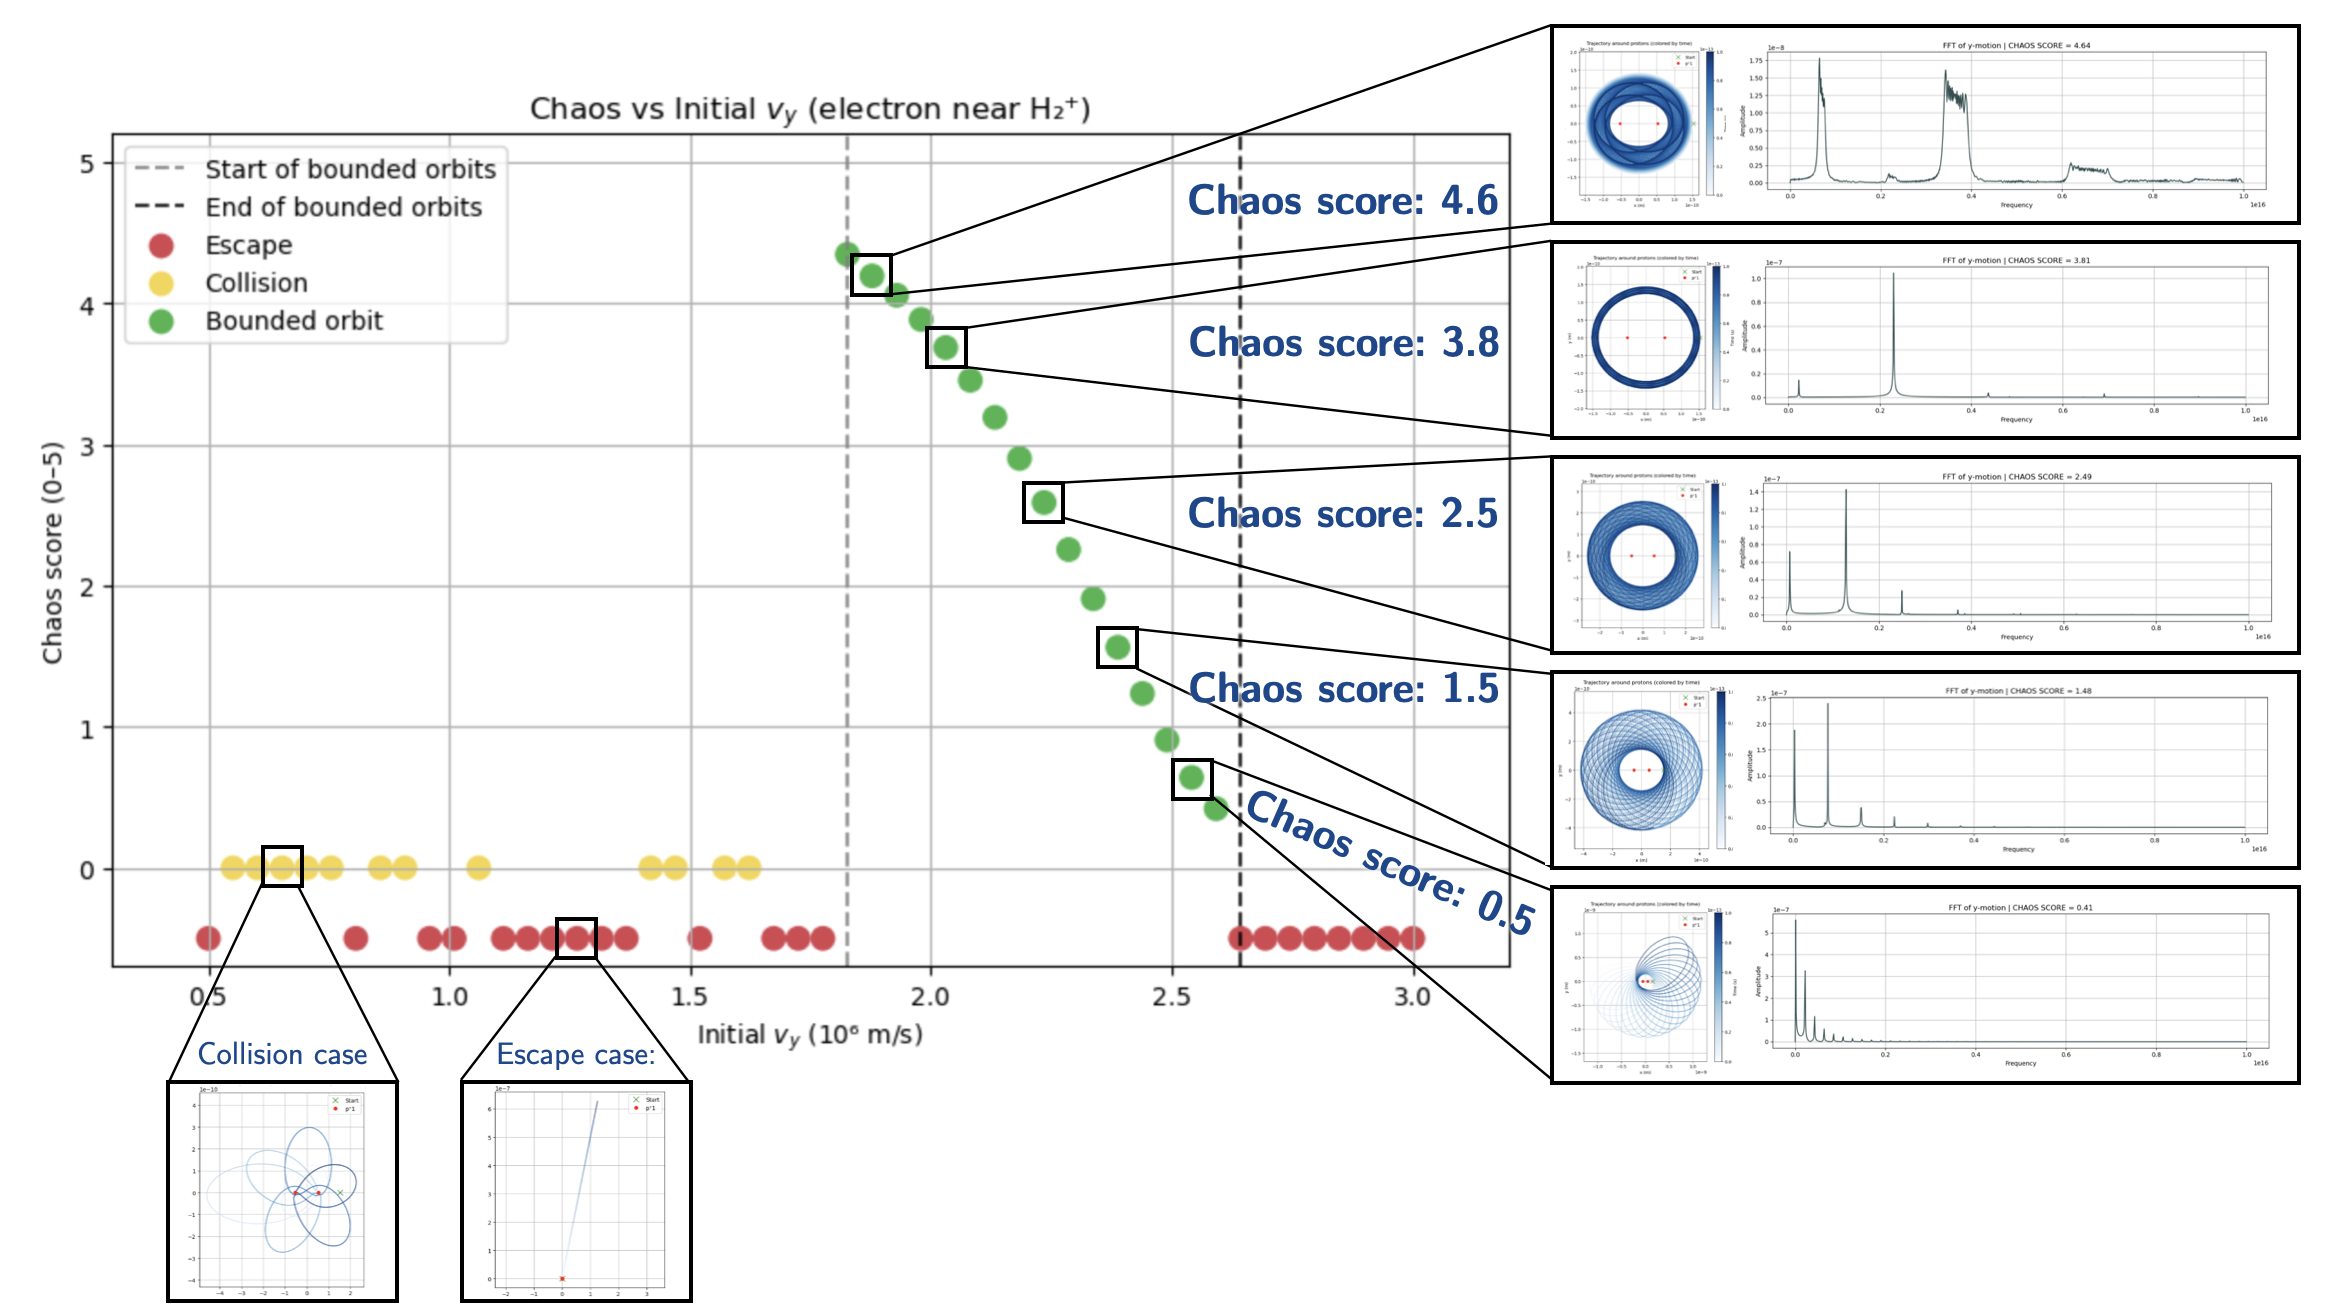

**Concluding Figure:** The chaos scatter plot annotated with different examples of orbits assigned different scores. Notice the simpler patterns have lower scores, and the complex patterns have higher scores. This is in line with how we set out to define chaocity in the beginning of the project. An escape case and a collision case are provided as an example. *Note: you can zoom in on the photo if needed.*

### Limitations:

Limitations on computation power and time meant that, for the sweep scatter plots to generate in a reasonable amount of time, the code that they used to simulate and time sweep was less intensive than the full electron–proton trajectory code with fine ODE step sizes. This means that the scatter plot will only offer a general idea of which velocities cause chaotic orbits. The trends are absolutely useful and generally representative of what one can expect of an orbit when selecting such velocities from the scatter plot, as shown in the Summary of Results.

### Next steps:

I would like to research methods to generate finer, more accurate scatter plot. Perhaps rescaling or normalizing the physical constants and velocities could reduce the strain on the ODE solver, if possible. This would allow the generation of finer-detailed plots. Fitting a value could also provide a piecewise function of chaos and velocity.

## $7\:$  $|$ $\:$**Acknowledgements**

- Fancy text (lowercase capitals) from https://lingojam.com/FancyTextGenerator.
- Generative AI was used to optimize and correct the code that generates the heat maps in the project.
- Generative AI was used to research methods of performing a Fourier transform on an velocity-time sinusoidal graph. I used the method it recommended, with <code>np.fft</code>.
- Generative AI was used to research a multitude of ways to make a 'chaocity score' from the Fourier transform.
- Generative AI was used to fix an assortment of bugs regarding how I wanted things to appear and be printed.
- Generative AI was used to source and cite articles correctly.

## $8\:$  $|$ $\:$**References**

**Code packages:**
- Used <code>numpy</code> for numerical code.
- Used <code>matplotlib</code> to plot graphs.
- Used <code>random</code> to generate random numbers.
- Used <code>tqdm</code> to generate little loading bars for computationally intensive tasks to update the user on how long it will take to finish generating a heat map.

**Articles:**
- Kalid Azad. An Interactive Guide to the Fourier Transform. BetterExplained, 2019. Available at: https://betterexplained.com/articles/an-interactive-guide-to-the-fourier-transform/ Accessed: October 30, 2025.
- H. Misra, S. Ikbal, H. Bourlard, and H. Hermansky, “Spectral entropy based feature for robust ASR,” in Proceedings of the 2004 IEEE International Conference on Acoustics, Speech, and Signal Processing (ICASSP 2004), Montreal, QC, Canada, May 17–21, 2004, pp. I-601–I-604, doi:10.1109/ICASSP.2004.132595.
- P. Atkins and R. Friedman. Molecular Quantum Mechanics. 5th ed. Oxford University Press, 2011.

---
<center> $⟨\;\boxed{\big|\text{ Appendix }\big|}\;⟩$
    
---

## **Appendix A** $|$ Physical justifications

### **A1.1** $|$ Code validation via energy conservation & ensuring long-term stability.

One way I will validate the code is through ensuring that energy is conserved utilizing the third graph generated for all orbits. Consider the below example. The energy-time graph is symmetrical. When the electron is farther away, it has more potential energy, which is quickly converted into kinetic energy as it approaches the center of the system. If the physics were not behaving properly, or energies were being calculated incorrectly, the energy-time graph would not me symmetrcal and thus energy would not be conserved.

I will also calculate the total energy and ensure it is less than zero (negative) to show that the energy conservation is working as intended.

$$E_\text{kinetic}+E_\text{potential}<0\text{, for proper energy conservation.}$$

Additionally, I calculate the change in total energy to quantitatively confirm that the energy drift remains small over the course of the simulation. This run generated an energy drift of 0.000359 %.

I will also run this particular case for 10 times as long to ensure the long-term stability of the periodic 'green' orbit-types generateed by the simulation.

This graph shows that the position, time and velocity of the proton is accurately solved in <code>solve_ivp</code>, which is the cornerstone of this investigation.

In [ ]:
# Time settings
T_guess = 10e-16
t_span = (0, 1000*T_guess)
max_step = T_guess/200

display(Markdown("#### **Trajectory behaviour:**"))
sol, verdict, KE, PE, E_total = run_simulation(2.50e6)
print('')
display(Markdown("#### **Trajectory graph, $v_y$ vs. time, and energy vs. time:**"))
plot_simulation(sol, KE, PE, E_total, protons, verdict)
plt.show()

**Figure A1.1 (all the way on the right):** the Energy vs Time graph is what we would expect of a properly-behaving simulation of an electron about a system of protons.

### **A1.2** $|$ Validating accuracy of the chaocity scatter plot.

Referring to the plots used in the Summary of Results, you can see that the velocity that generated such a plot roughly correspond to what chaos score the scatter plot predicted it would. Below is a table for reference.

| Behaviour Type      | $v_y$ (m/s)                   | Chaos Score from Simulation | Chaos Score from Graph |
|----------------------|--------------------------------------|--------------|-------------------------------|
| **Chaotic**          | $ 1.80\times10^6$   | 4.64    | ~4.5 |
| **Somewhat chaotic** | $ 2.25\times10^6$   | 2.49    | ~2.5 |
| **Least chaotic**    | $ 1.50\times10^6$   | 0.87    | ~0.9 |

The table indicates that the table has a fair degree of accuracy to what kind of score/chaos you might expect when choosing values to test in the simulation code. 

### **A1.3** $|$  Physical justifications of constants for thresholds used.

#### *Collision threshold:* $1\times10^{-12}\text{ m}$
The Bohr radius is $a_0=5.29\times 10^{-11}\text{ m}$, which mdans the chosen collision threshold is about 2% of the Bohr radius. This distance is very small, much smaller than classical mechanics and Coulomb's law permit for meaninful results. This makes this distance an adequate lower bound.

#### *Escape threshold:* $1\times10^{-9}\text{ m}$
The escape radius is approximately 12.5 times the proton spacing in this simulation, and approximately 20 Bohr radii. This results in the electron-proton force felt by one-another being extremely decreased and renders it safe to assume that an electron on such a trajectory will not be tugged back by the protons ($F\propto\frac{1}{r^2}=\frac{1}{400}\text{ths}$ as strong).

#### *Integration duration:* $100\times \;$<code>T_guess</code>
The orbital period of an electron about a hydrogen is approximately $1.52\times 10^{-16}\text{ s}$, so I chose a <code>T_guess</code> of $2\times 10^{-16}\text{ s}$ and multiplied it by 100 to give a full picture of the long-term behaviour of the electron over many periods. It is no larger, however, as I wanted to ensure the computational aspect remained efficient.

### **A1.4** $|$  Solver stability.

By halving <code>max_step</code> (changing from <code>T_guess/200</code> to <code>T_guess/400</code>), we can show that the solver stays stable with the finer computations. Below is the result.

In [ ]:
# Time settings
T_guess = 10e-16
t_span = (0, 100*T_guess)
max_step = T_guess/400

display(Markdown("#### **Trajectory behaviour:**"))
sol, verdict, KE, PE, E_total = run_simulation(2.50e6)
print('')

The solver stays stable when given finer steps to work with. The maximum energy change is below 0.00001 %. This indicates that the total energy stays consistent.

---

## **Appendix B** $|$ Reflection questions

### Reflection 1: Coding Approaches (A)
*(How well did you apply and extend your coding knowledge in this project? Consider steps you took to make the code more efficient, readable and/or concise. Discuss any new-to-you coding techniques, functions or python packages that you learned how to use. Reflect on any unforeseen coding challenges you faced in completing this project.)*

I really struggled with this project. I had to get a lot of help from Generative AI to make the code actually do what I had envisioned in my head. The project in this state is all my own ideas, however. I researched about Fourier transforms and applied the python function that does it automatically. I also learned how to use a loading bar python package to make the user process more friendly and responsive. This project uses sweeping, which was a skill I had developed earlier in my previous project.

### Reflection 2: Coding Approaches (B)
*(Highlight an aspect of your code that you feel you did particularily well. Discuss an aspect of your code that would benefit the most from further effort.)*

I think the final graph is a very functional and helpful tool and was excited to see a pattern emerge in the collide-escape-stable graph. More work could be put into refining the calculation of different chaos scores around the extrema, where the deviation between the sweeped chaos score and simulated ones are larger.

### Reflection 3: Simulation physics and investigation (A)
*(How well did you apply and extend your physical modelling and scientific investigation skills in this project? Consider the phase space you chose to explore and how throroughly you explored it. Consider how you translated physics into code and if appropriate any new physics you learned or developed a more thorough understanding of.)*

I learned a lot about different ways to model physics in this project. I was previously only aware of Euler's method, however solve IVP is a very powerful tool and a great introduction to the power of ODE's for me. I explored the velocity phase space thoroughly by running a sweep and plotting the graph in the conclusion. I learned about Fourier transforms and applied it to my project in an interesting way to diagnose the chaos of the system.

### Reflection 4: Simulation phyiscs and investigation (B)
*(Highlight something you feel you did particularily well in terms of the context of your simulation, the physical modelling that you did or the investigation you performed. Discuss an aspect of these dimensions of your project that would benefit the most from further effort.)*

I think the layout of investigation is really strong. I had a really clear vision for what question I wanted to ask and how I could answer it with one graph. I learned about two very powerful tools, the Fourier transform and the metrics to generate a chaos score. An area of improvement could be improving the way my sweep works, and make it report more accurate chaos scores for different velocities. 

### Reflection 5: Effectiveness of your communication
*(Highlight something you feel you did particularily well in your visualizations or written communication. Discuss an aspect of your visualizations or written communication that would benefit the most from further effort.)*

I think the layout of the report is really clean and guides the reader through well. I think the plots are clear and the descriptions are apt. Further benefit could be a more accurate final graph as well.

<center> Thank you! ☺︎